## Feature Engineering - Diabetes

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-18

## 📚 Import  libraries

In [4]:
from pathlib import Path

import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

## 💾 Load data

In [5]:
DATA_INTERMEDIA = Path("../../data/02_intermediate/diabetes_type_fixed.parquet")
df = pd.read_parquet(DATA_INTERMEDIA)
df.shape

(994, 9)

In [6]:
df.isna().sum()

Pregnancies                   8
Glucose                      12
BloodPressure                52
SkinThickness               305
Insulin                     493
BMI                          16
DiabetesPedigreeFunction      5
Age                           3
Outcome                      19
dtype: int64

## 👷 Data preparation or Feature Engineering

## Decisiones:

- El outlier extremo de `SkinThickness` (~99) identificado en el EDA se deja sin
  modificar: no hay evidencia de que sea un error de captura (a diferencia del bug
  de escala de `DiabetesPedigreeFunction`, confirmado y corregido en la exploración inicial), así
  que tratarlo como error sería un supuesto no justificado.
- No se aplica escalado (`StandardScaler`) en esta tarea; se decide en el paso siguiente que son los modelos,
  según el modelo baseline elegido.
- No se crean variables nuevas (no hay variables categóricas para combinar ni
  justificación clara para features derivadas en este dataset), por lo que no aplica en este proyecto.
- Orden de limpieza: primero se eliminan las filas sin `Outcome` (no sirven ni para
  entrenar ni para evaluar), luego los duplicados sobre lo que queda — así se evita
  eliminar por accidente la copia con `Outcome` conocido de una fila duplicada.
- El split train/test se hace **antes** de ajustar el imputador, y el imputador se
  ajusta **solo con train**, para evitar data leakage.

## Limpieza: filas sin Outcome y duplicados

In [7]:
n_inicial = len(df)

df = df[df["Outcome"].notna()].copy()
n_sin_target = n_inicial - len(df)

n_antes_dedup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_duplicados = n_antes_dedup - len(df)

print(f"Filas eliminadas por Outcome faltante: {n_sin_target}")
print(f"Filas eliminadas por duplicados: {n_duplicados}")
print(f"Filas finales: {len(df)}")

Filas eliminadas por Outcome faltante: 19
Filas eliminadas por duplicados: 188
Filas finales: 787


In [8]:
DATA_PRIMARY = Path("../../data/03_primary/diabetes_clean.parquet")
DATA_PRIMARY.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(DATA_PRIMARY, index=False)

## Separación train/test (antes de imputar, para evitar data leakage)

In [9]:
COLUMNAS_FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET = "Outcome"
PROPORCION_TEST = 0.2
SEMILLA = 42

X = df[COLUMNAS_FEATURES]
y = df[TARGET].astype(bool)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, stratify=y, random_state=SEMILLA
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("\nProporción de Outcome en train:")
print(y_train.value_counts(normalize=True))
print("\nProporción de Outcome en test:")
print(y_test.value_counts(normalize=True))

Train: 629 filas | Test: 158 filas

Proporción de Outcome en train:
Outcome
False    0.647059
True     0.352941
Name: proportion, dtype: float64

Proporción de Outcome en test:
Outcome
False    0.64557
True     0.35443
Name: proportion, dtype: float64


## Imputación (mediana), ajustada solo con train

In [10]:
preprocesador = ColumnTransformer(
    transformers=[
        ("imputer_mediana", SimpleImputer(strategy="median"), COLUMNAS_FEATURES),
    ],
    verbose_feature_names_out=False,
)
preprocesador.set_output(transform="pandas")

preprocesador.fit(X_train)

X_train_imputado = preprocesador.transform(X_train)[COLUMNAS_FEATURES]
X_test_imputado = preprocesador.transform(X_test)[COLUMNAS_FEATURES]

print("Nulos en X_train tras imputación:")
print(X_train_imputado.isna().sum())
print("\nNulos en X_test tras imputación:")
print(X_test_imputado.isna().sum())

Nulos en X_train tras imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Nulos en X_test tras imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


## Transformación logarítmica de variables sesgadas

`Insulin` y `DiabetesPedigreeFunction` mostraron el mayor sesgo y kurtosis en el
análisis univariable de la Tarea 3 (skew 2.28/1.86, kurtosis 7.24/5.10). Se aplica
`log1p` (log(1+x), evita problemas con valores en cero) para reducir el sesgo y
ayudar a modelos sensibles a la forma de la distribución. No requiere ajuste
(`fit`): es una transformación matemática determinista, se aplica igual a train y
test sin riesgo de fuga de información.

In [11]:
import numpy as np
from scipy.stats import skew

COLUMNAS_SESGADAS = ["Insulin", "DiabetesPedigreeFunction"]

print("Skewness antes de la transformacion:")
for col in COLUMNAS_SESGADAS:
    print(
        f"  {col}: train={skew(X_train_imputado[col]):.3f}, test={skew(X_test_imputado[col]):.3f}"
    )

for col in COLUMNAS_SESGADAS:
    X_train_imputado[col] = np.log1p(X_train_imputado[col])
    X_test_imputado[col] = np.log1p(X_test_imputado[col])

print("\nSkewness despues de la transformacion:")
for col in COLUMNAS_SESGADAS:
    print(
        f"  {col}: train={skew(X_train_imputado[col]):.3f}, test={skew(X_test_imputado[col]):.3f}"
    )

Skewness antes de la transformacion:
  Insulin: train=3.556, test=2.757
  DiabetesPedigreeFunction: train=1.878, test=2.123

Skewness despues de la transformacion:
  Insulin: train=-0.128, test=-0.452
  DiabetesPedigreeFunction: train=1.100, test=1.166


## Selección de features

Con 8 variables predictoras (pocas comparado con el uso típico de selección de
atributos, que busca reducir cientos/miles de variables), el objetivo aquí no es
reducir dimensionalidad por riesgo de sobreajuste, sino **documentar de forma
cuantitativa la relación individual de cada variable con `Outcome`**, como
insumo para decidir si alguna variable debe descartarse antes de modelar.

Se usan dos métodos complementarios, ambos ajustados solo con `X_train_imputado`/
`y_train` (después de imputación y `log1p`, para evitar data leakage):
- **ANOVA F-value** (`f_classif`): mide si la media de cada variable difiere
significativamente entre las clases (asume relación aproximadamente lineal).
 **Mutual Information** (`mutual_info_classif`): no asume linealidad, captura
también relaciones no lineales entre cada variable y el target.

In [12]:
from sklearn.feature_selection import f_classif, mutual_info_classif

f_scores, f_pvalues = f_classif(X_train_imputado, y_train)
mi_scores = mutual_info_classif(X_train_imputado, y_train, random_state=SEMILLA)

seleccion_features = (
    pd.DataFrame(
        {
            "feature": COLUMNAS_FEATURES,
            "f_score": f_scores,
            "f_pvalue": f_pvalues,
            "mutual_info": mi_scores,
        }
    )
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

seleccion_features

,feature,f_score,f_pvalue,mutual_info
0,Glucose,166.988496,4.906380e-34,0.118785
1,BMI,64.580305,4.615882e-15,0.072026
2,Insulin,43.790042,7.849316e-11,0.056380
3,Age,41.607903,2.230445e-10,0.062826
4,SkinThickness,38.019199,1.255111e-09,0.074544
5,Pregnancies,37.420918,1.676146e-09,0.020717
6,DiabetesPedigreeFunction,19.499647,1.184989e-05,0.024901
7,BloodPressure,15.545794,8.960575e-05,0.041641


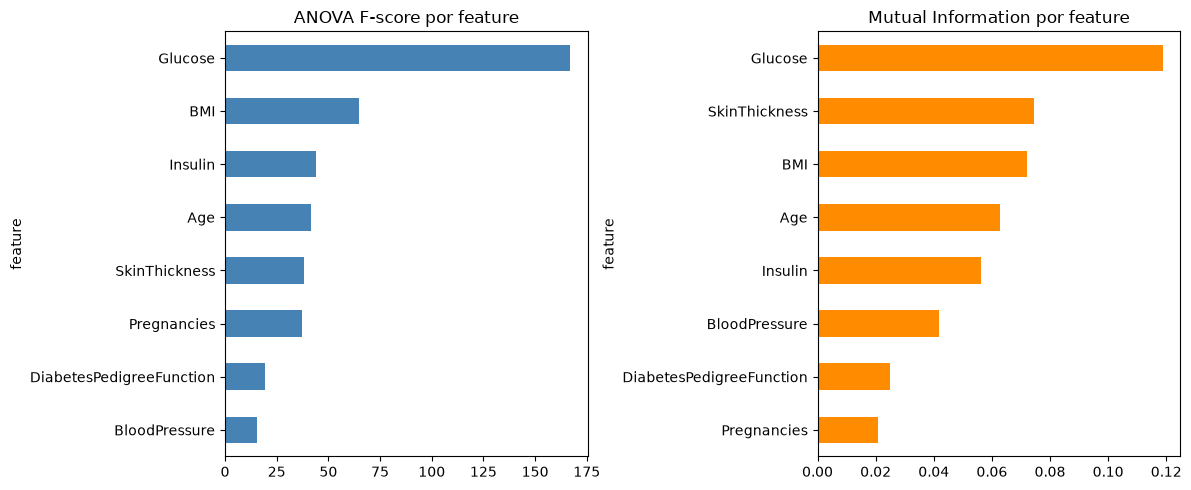

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

seleccion_features.plot.barh(x="feature", y="f_score", ax=axes[0], legend=False, color="steelblue")
axes[0].set_title("ANOVA F-score por feature")
axes[0].invert_yaxis()

seleccion_features.sort_values("mutual_info", ascending=False).plot.barh(
    x="feature", y="mutual_info", ax=axes[1], legend=False, color="darkorange"
)
axes[1].set_title("Mutual Information por feature")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../../data/08_reporting/feature_selection_scores.png", dpi=100)
plt.show()

### Decisión: se mantienen las 8 variables

Los resultados muestran que las 8 variables tienen una asociación estadísticamente
significativa con `Outcome` (ANOVA F-test, p < 0.05 en todos los casos, la más débil
en p≈8.96e-5 para `BloodPressure`) y Mutual Information positiva en todas (entre
0.021 y 0.119), confirmando también relaciones no lineales.

- `Glucose` domina por un margen amplio en ambos métodos (F=166.99, MI=0.119),
  consistente con el EDA y el baseline heurístico.
- `BMI` es la segunda variable más fuerte por F-score (64.58) y está en el top 3 por MI (0.072).
- El orden de las variables intermedias (`Insulin`, `Age`, `SkinThickness`, `Pregnancies`)
  cambia entre F-score y Mutual Information — esperable con un tamaño de muestra
  moderado (629 filas de train) y dos métodos que capturan tipos de relación distintos.
- `DiabetesPedigreeFunction` y `BloodPressure` son las más débiles por F-score (19.50 y
  15.55), pero siguen siendo significativas (p < 0.0001), y ninguna es la más débil por
  Mutual Information (ese lugar lo ocupa `Pregnancies`, con 0.021) — ningún método por
  sí solo señala una variable claramente prescindible.

Con solo 8 variables predictoras, un dataset pequeño (629 filas de train) y ninguna
variable estadísticamente irrelevante, no hay justificación basada en evidencia para
eliminar ninguna. Se mantienen las 8 para el modelado. Esta decisión es consistente
con el hallazgo posterior de la interpretación del modelo, donde `BMI` y
`Age` mostraron señal secundaria pero real, y el resto aportó señal individual baja
pero no nula.

## Demostración de escalado de atributos

Se demuestra aquí con `StandardScaler` ajustado solo con train, pero **no se persiste
en los datos guardados**: el escalado se aplica dentro de los pipelines de
modelado en las Tareas 5 y 6, porque no todos los modelos lo necesitan (los
basados en árboles son invariantes a esto) — aplicarlo aquí de forma fija
obligaría a todos los modelos futuros a usar datos ya escalados, incluso los que
no lo requieren.

In [14]:
from sklearn.preprocessing import StandardScaler

escalador_demo = StandardScaler()
X_train_escalado_demo = escalador_demo.fit_transform(X_train_imputado)

print("Media por columna tras escalar (deben ser ~0):")
print(np.round(X_train_escalado_demo.mean(axis=0), 3))
print("\nDesviacion estandar por columna tras escalar (deben ser ~1):")
print(np.round(X_train_escalado_demo.std(axis=0), 3))

Media por columna tras escalar (deben ser ~0):
[ 0.  0. -0.  0.  0.  0. -0. -0.]

Desviacion estandar por columna tras escalar (deben ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
train_final = X_train_imputado.assign(Outcome=y_train)
test_final = X_test_imputado.assign(Outcome=y_test)

MODEL_INPUT_DIR = Path("../../data/05_model_input")
MODEL_INPUT_DIR.mkdir(parents=True, exist_ok=True)
train_final.to_parquet(MODEL_INPUT_DIR / "train.parquet", index=False)
test_final.to_parquet(MODEL_INPUT_DIR / "test.parquet", index=False)

print(f"train.parquet: {train_final.shape}")
print(f"test.parquet: {test_final.shape}")

train.parquet: (629, 9)
test.parquet: (158, 9)


In [16]:
MODELS_DIR = Path("../../data/06_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(preprocesador, MODELS_DIR / "preprocesador_imputacion.joblib")

['../../data/06_models/preprocesador_imputacion.joblib']

## 📊 Hallazgos - Feature Engineering


### Limpieza
- Se eliminaron 19 filas sin `Outcome` (no sirven para entrenar ni evaluar).
- Sobre las 975 filas restantes, se eliminaron 188 duplicados exactos (19.3%),
  quedando un dataset limpio de **787 filas**.

### Missingness (nulos reales, no ceros disfrazados)
| Columna | Nulos | % |
|---|---|---|
| Insulin | 387 | 49.2% |
| SkinThickness | 242 | 30.8% |
| BloodPressure | 40 | 5.1% |
| BMI | 13 | 1.7% |
| Glucose | 10 | 1.3% |
| Pregnancies | 6 | 0.8% |
| DiabetesPedigreeFunction | 4 | 0.5% |
| Age | 3 | 0.4% |

Insulin y SkinThickness confirman el nivel de missingness ya detectado en el EDA.
Pregnancies, DiabetesPedigreeFunction y Age son un hallazgo nuevo: nulos
genuinos no capturados en las validaciones del entendimiento del problema y la exploración inicial de datos (que solo revisaban ceros
disfrazados y el bug de escala de DPF). Por eso el imputador se aplicó finalmente a las
8 variables numéricas (no solo a las 5 detectadas originalmente), evitando dejar nulos
sin tratar por una lista incompleta.

### Split train/test
- 629 filas de train (64.7% False / 35.3% True) y 158 de test (64.6% False / 35.4% True),
  proporciones prácticamente idénticas gracias a `stratify=Outcome`.

### Decisiones registradas
- El outlier extremo de SkinThickness (~99) se deja sin modificar: no hay evidencia de
  que sea un error de captura.
- No se aplica escalado (`StandardScaler`) en esta tarea; queda pendiente para la Tarea 5
  según el modelo baseline elegido.
- No se generan variables nuevas; `data/04_feature/` no se usa en este proyecto.